In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [26]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [27]:
checker = pd.io.sql.read_sql(
    "SELECT timestamp FROM checker WHERE uid LIKE 'user_%'",
    conn,
    parse_dates=['timestamp']
)
checker

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370
...,...
3202,2020-05-21 20:19:06.872761
3203,2020-05-21 20:22:41.785725
3204,2020-05-21 20:22:41.877806
3205,2020-05-21 20:37:00.129678


In [28]:
checker['hour'] = checker['timestamp'].dt.hour
checker['day_of_week'] = checker['timestamp'].dt.dayofweek
checker['day_type'] = checker['day_of_week'].apply(lambda x: 'weekend' if x >= 5 else 'working_day')
checker

,timestamp,hour,day_of_week,day_type
0,2020-04-17 05:19:02.744528,5,4,working_day
1,2020-04-17 05:22:35.249331,5,4,working_day
2,2020-04-17 05:22:45.549397,5,4,working_day
3,2020-04-17 05:34:14.691200,5,4,working_day
4,2020-04-17 05:34:24.422370,5,4,working_day
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,20,3,working_day
3203,2020-05-21 20:22:41.785725,20,3,working_day
3204,2020-05-21 20:22:41.877806,20,3,working_day
3205,2020-05-21 20:37:00.129678,20,3,working_day


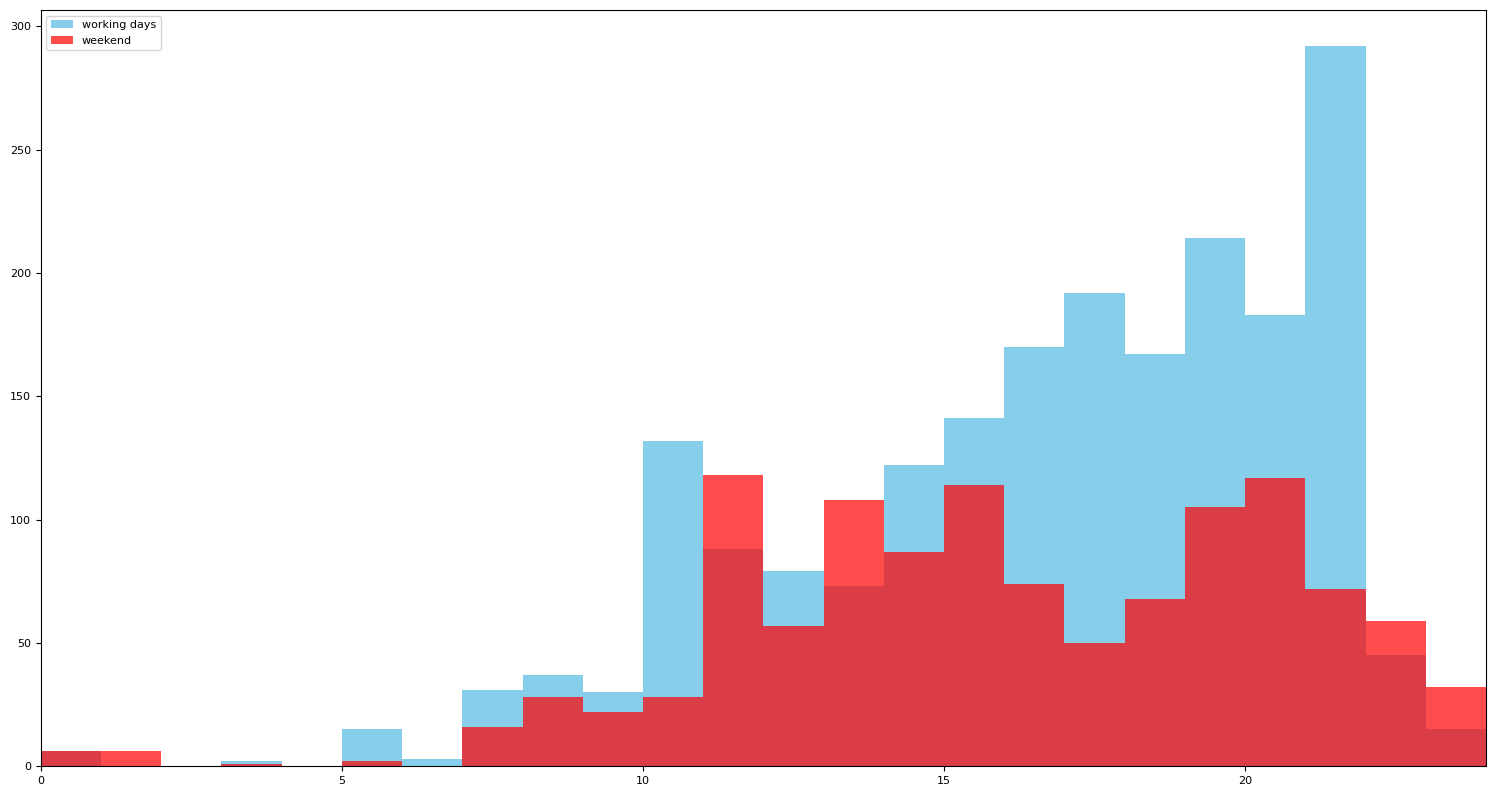

In [29]:
working_day_hours = checker[checker['day_type'] == 'working_day']['hour'].tolist()
weekend_hours = checker[checker['day_type'] == 'weekend']['hour'].tolist()

plt.rcParams['font.size'] = 8
plt.figure(figsize=(15, 8))
plt.hist(working_day_hours, bins=24, range=(0, 24), color='#87CEEB', label='working days')
plt.hist(weekend_hours, bins=24, range=(0, 24), color='#FF0000', label='weekend', alpha=0.7)
plt.xlim(0, 24)
plt.xticks(range(0, 24, 5))
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
conn.close()

**Есть ли часы, в которые общее число коммитов в выходные было больше, чем в будни?**

**Ответ:** Да, такие часы есть. Ниже приведен топ-4 примеров:
1. Час 11 (11:00-11:59);
2. Час 13 (13:00-13:59);
3. Час 22 (22:00-22:59);
4. Час 23 (23:00-23:59).